In [3]:
import pandas as pd

# 1. Carregando as duas bases 
df_det = pd.read_csv('../data/processed/dados_toxicidade_reddit_100k.csv')
df_per = pd.read_csv('../data/processed/toxicidade_perspective_100k.csv')

# 2. Fazendo o Merge pelo ID E pelo Texto (A CORREÇÃO ESTÁ AQUI)
# Isso evita que o Pandas duplique a coluna de texto e crie sufixos nela
df_comp = pd.merge(df_det, df_per, on=['id', 'text_clean'], suffixes=('_det', '_per'))

# 3. Calculando a Diferença Absoluta (A Discrepância)
df_comp['discrepancia'] = abs(df_comp['perspective_toxicity'] - df_comp['toxicity'])

# 4. Filtrando os Extremos (A "Guerra" dos Modelos)
cenario_a = df_comp[(df_comp['perspective_toxicity'] > 0.7) & (df_comp['toxicity'] < 0.3)]
top_50_perspective_vence = cenario_a.sort_values(by='discrepancia', ascending=False).head(50)

cenario_b = df_comp[(df_comp['toxicity'] > 0.7) & (df_comp['perspective_toxicity'] < 0.3)]
top_50_detoxify_vence = cenario_b.sort_values(by='discrepancia', ascending=False).head(50)

# 5. Salvando para você fazer a Análise Qualitativa
colunas_leitura = ['id', 'text_clean', 'toxicity', 'perspective_toxicity', 'discrepancia']

top_50_perspective_vence[colunas_leitura].to_csv('../data/processed/analise_manual_perspective_alto.csv', index=False)
top_50_detoxify_vence[colunas_leitura].to_csv('../data/processed/analise_manual_detoxify_alto.csv', index=False)

print(f"✅ Bases prontas! Foram encontrados {len(cenario_a)} casos pró-Perspective e {len(cenario_b)} pró-Detoxify.")

✅ Bases prontas! Foram encontrados 21 casos pró-Perspective e 493 pró-Detoxify.


In [4]:
import pandas as pd
from langdetect import detect
from tqdm import tqdm

# Habilita a barra de progresso no Pandas
tqdm.pandas(desc="Detectando Idioma")

# 1. Carrega a tabela já unida (com os 95.083 posts)
df_det = pd.read_csv('../data/processed/dados_toxicidade_reddit_100k.csv')
df_per = pd.read_csv('../data/processed/toxicidade_perspective_100k.csv')
df_comp = pd.merge(df_det, df_per, on=['id', 'text_clean'], suffixes=('_det', '_per'))

# 2. Função de proteção para detectar o idioma
def checar_ingles(texto):
    try:
        # Pega apenas os primeiros 200 caracteres para ser super rápido
        return detect(str(texto)[:200]) == 'en'
    except:
        return False

print(f"Total de posts originais: {len(df_comp)}")
print("🔍 Iniciando detecção de idioma (Isso pode levar uns 2-3 minutos)...")

# 3. Aplica o filtro
df_comp['is_english'] = df_comp['text_clean'].progress_apply(checar_ingles)

# 4. Cria a base final só com Inglês
df_english = df_comp[df_comp['is_english'] == True].copy()
df_english = df_english.drop(columns=['is_english']) # Remove a coluna de marcação

removidos = len(df_comp) - len(df_english)
print(f"✅ Limpeza concluída! {removidos} posts em outros idiomas foram descartados.")
print(f"📊 Nova base 100% em inglês possui {len(df_english)} posts.")

# 5. Recalculando a "Guerra" dos Modelos agora de forma justa
df_english['discrepancia'] = abs(df_english['perspective_toxicity'] - df_english['toxicity'])

cenario_a = df_english[(df_english['perspective_toxicity'] > 0.7) & (df_english['toxicity'] < 0.3)]
top_50_perspective = cenario_a.sort_values(by='discrepancia', ascending=False).head(50)

cenario_b = df_english[(df_english['toxicity'] > 0.7) & (df_english['perspective_toxicity'] < 0.3)]
top_50_detoxify = cenario_b.sort_values(by='discrepancia', ascending=False).head(50)

colunas = ['id', 'text_clean', 'toxicity', 'perspective_toxicity', 'discrepancia']

# Salvando as novas bases limpas
df_english.to_csv('../data/processed/base_final_comparacao_ingles.csv', index=False)
top_50_perspective[colunas].to_csv('../data/processed/analise_manual_perspective_ingles.csv', index=False)
top_50_detoxify[colunas].to_csv('../data/processed/analise_manual_detoxify_ingles.csv', index=False)

print(f"✨ Arquivos atualizados gerados com sucesso!")
print(f"Discordâncias JUSTAS -> Pró-Perspective: {len(cenario_a)} | Pró-Detoxify: {len(cenario_b)}")

Total de posts originais: 95083
🔍 Iniciando detecção de idioma (Isso pode levar uns 2-3 minutos)...


Detectando Idioma: 100%|██████████| 95083/95083 [05:48<00:00, 273.01it/s]


✅ Limpeza concluída! 31796 posts em outros idiomas foram descartados.
📊 Nova base 100% em inglês possui 63287 posts.
✨ Arquivos atualizados gerados com sucesso!
Discordâncias JUSTAS -> Pró-Perspective: 8 | Pró-Detoxify: 220


📊 --- RESULTADOS DA CORRELAÇÃO ---
Coeficiente de Spearman: 0.7950
P-valor: 0.0000e+00

📸 Gráfico atualizado salvo com sucesso!


<Figure size 1000x800 with 0 Axes>

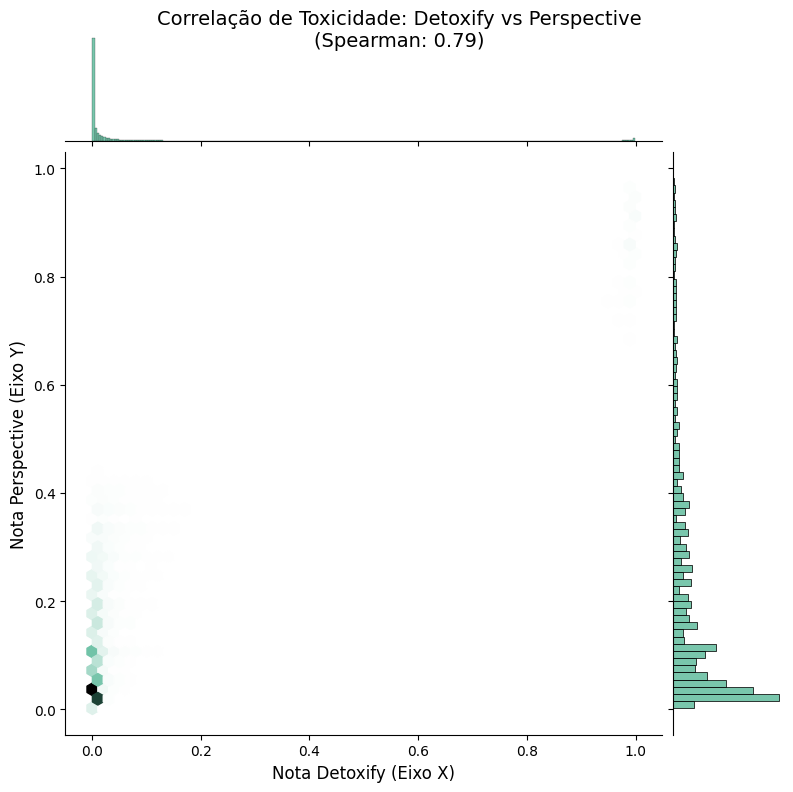

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# 1. Carregar a base limpa (100% em inglês)
df = pd.read_csv('../data/processed/base_final_comparacao_ingles.csv')

# --- A CORREÇÃO ESTÁ AQUI ---
# Remove qualquer post que por acaso tenha ficado sem nota (nulo/NaN)
df_clean = df.dropna(subset=['toxicity', 'perspective_toxicity']).copy()

# 2. Calcular a Correlação de Spearman com os dados limpinhos
corr, p_value = spearmanr(df_clean['toxicity'], df_clean['perspective_toxicity'])

print("📊 --- RESULTADOS DA CORRELAÇÃO ---")
print(f"Coeficiente de Spearman: {corr:.4f}")
print(f"P-valor: {p_value:.4e}\n")

# 3. Gerar o Gráfico Hexagonal
plt.figure(figsize=(10, 8))

grafico = sns.jointplot(
    x=df_clean['toxicity'], 
    y=df_clean['perspective_toxicity'], 
    kind="hex", 
    color="#4CB391",
    height=8,
    space=0.1
)

grafico.set_axis_labels('Nota Detoxify (Eixo X)', 'Nota Perspective (Eixo Y)', fontsize=12)
plt.subplots_adjust(top=0.95)
grafico.fig.suptitle(f'Correlação de Toxicidade: Detoxify vs Perspective\n(Spearman: {corr:.2f})', fontsize=14)

plt.savefig('../data/processed/grafico_correlacao_modelos.png', dpi=300, bbox_inches='tight')
print("📸 Gráfico atualizado salvo com sucesso!")

plt.show()

📊 Carregando a base de dados...
🎨 Gerando o gráfico de comparação...
✅ Gráfico gerado com sucesso e salvo em: ../data/processed/grafico_linhas_modelos.png


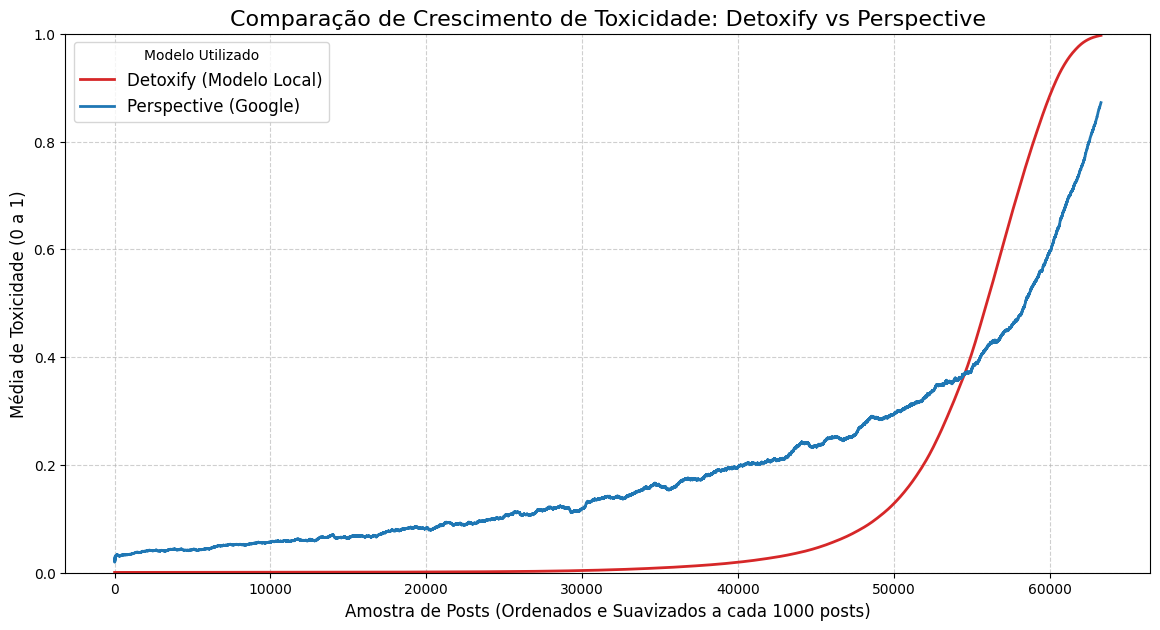

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

print("📊 Carregando a base de dados...")
# Carrega a sua base final limpa
df = pd.read_csv('../data/processed/base_final_comparacao_ingles.csv')

# Ordenamos pelo Detoxify para criar a linha de base crescente
df_sorted = df.sort_values('toxicity').reset_index(drop=True)

# Calculamos a Média Móvel (agrupando de 1000 em 1000 posts) para não virar um rabisco
janela = 1000
df_smooth = df_sorted[['toxicity', 'perspective_toxicity']].rolling(window=janela, min_periods=1).mean()

print("🎨 Gerando o gráfico de comparação...")
plt.figure(figsize=(14, 7))

# Plotando as duas linhas
plt.plot(df_smooth.index, df_smooth['toxicity'], label='Detoxify (Modelo Local)', color='#d62728', linewidth=2)
plt.plot(df_smooth.index, df_smooth['perspective_toxicity'], label='Perspective (Google)', color='#1f77b4', linewidth=2)

# Configurações do gráfico para ficar igual ao seu exemplo
plt.ylim(0, 1.0) # Força o eixo Y a ir de 0 a 1
plt.title('Comparação de Crescimento de Toxicidade: Detoxify vs Perspective', fontsize=16)
plt.ylabel('Média de Toxicidade (0 a 1)', fontsize=12)
plt.xlabel(f'Amostra de Posts (Ordenados e Suavizados a cada {janela} posts)', fontsize=12)

# Adiciona linhas de grade e legenda
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title="Modelo Utilizado", fontsize=12, loc='upper left')

# Salva a imagem
caminho_imagem = '../data/processed/grafico_linhas_modelos.png'
plt.savefig(caminho_imagem, dpi=300, bbox_inches='tight')

print(f"✅ Gráfico gerado com sucesso e salvo em: {caminho_imagem}")
plt.show()

📊 Carregando a base de dados...
🎨 Gerando o gráfico invertido (Distribuição Cumulativa)...
✅ Gráfico gerado com sucesso e salvo em: ../data/processed/grafico_cdf_modelos.png


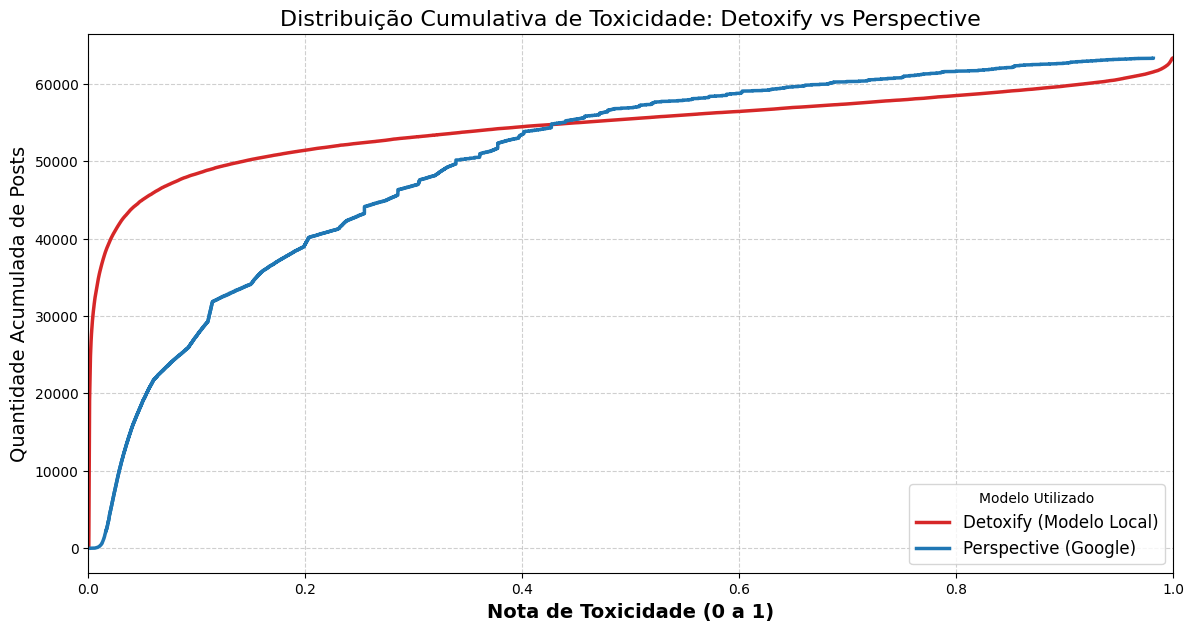

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

print("📊 Carregando a base de dados...")
df = pd.read_csv('../data/processed/base_final_comparacao_ingles.csv')

# Ordenamos as notas de cada modelo separadamente para a curva crescer perfeitamente no Eixo X
detoxify_sorted = df['toxicity'].sort_values().reset_index(drop=True)
perspective_sorted = df['perspective_toxicity'].sort_values().reset_index(drop=True)

print("🎨 Gerando o gráfico invertido (Distribuição Cumulativa)...")
plt.figure(figsize=(14, 7))

# Agora o Eixo X recebe a nota (0 a 1) e o Eixo Y recebe a contagem de posts (o index)
plt.plot(detoxify_sorted, detoxify_sorted.index, label='Detoxify (Modelo Local)', color='#d62728', linewidth=2.5)
plt.plot(perspective_sorted, perspective_sorted.index, label='Perspective (Google)', color='#1f77b4', linewidth=2.5)

# Força o eixo X a ir estritamente de 0.0 a 1.0
plt.xlim(0, 1.0) 

# Estilização
plt.title('Distribuição Cumulativa de Toxicidade: Detoxify vs Perspective', fontsize=16)
plt.xlabel('Nota de Toxicidade (0 a 1)', fontsize=14, fontweight='bold')
plt.ylabel('Quantidade Acumulada de Posts', fontsize=14)

# Adiciona linhas de grade e ajusta a legenda
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title="Modelo Utilizado", fontsize=12, loc='lower right')

# Salva a imagem
caminho_imagem = '../data/processed/grafico_cdf_modelos.png'
plt.savefig(caminho_imagem, dpi=300, bbox_inches='tight')

print(f"✅ Gráfico gerado com sucesso e salvo em: {caminho_imagem}")
plt.show()

In [2]:
import pandas as pd

print("⏳ Carregando a base de dados...")
df = pd.read_csv('../data/processed/base_final_comparacao_ingles.csv')

coluna_txt = 'text_clean'

# Filtros
detox_alto_persp_baixo = df[(df['toxicity'] > 0.8) & (df['perspective_toxicity'] < 0.4)].head(5)
persp_alto_detox_baixo = df[(df['perspective_toxicity'] > 0.6) & (df['toxicity'] < 0.3)].head(5)
ambos_concordam = df[(df['toxicity'] > 0.7) & (df['perspective_toxicity'] > 0.7) & 
                     (abs(df['toxicity'] - df['perspective_toxicity']) < 0.1)].head(5)

# Nome do arquivo que será criado
caminho_arquivo = 'exemplos_para_o_professor.txt'

# Abrindo o arquivo para escrever (modo 'w')
with open(caminho_arquivo, 'w', encoding='utf-8') as f:
    
    def escrever_casos(dataframe, titulo):
        f.write(f"\n{'='*60}\n")
        f.write(f"📌 {titulo}\n")
        f.write(f"{'='*60}\n")
        for i, row in enumerate(dataframe.itertuples(), 1):
            texto = str(getattr(row, coluna_txt))
            
            f.write(f"Exemplo {i}:\n")
            f.write(f"Texto: \"{texto}\"\n")
            f.write(f"Nota Detoxify:   {row.toxicity:.2f}\n")
            f.write(f"Nota Perspective: {row.perspective_toxicity:.2f}\n")
            f.write("-" * 40 + "\n")

    # Gravando os resultados no arquivo
    escrever_casos(detox_alto_persp_baixo, "CENÁRIO 1: Detoxify exagerou (Alto) / Perspective perdoou (Baixo)")
    escrever_casos(persp_alto_detox_baixo, "CENÁRIO 2: Perspective pegou o contexto (Alto) / Detoxify ignorou (Baixo)")
    escrever_casos(ambos_concordam, "CENÁRIO 3: Os dois modelos concordam (Ambos Altos)")

print(f"✅ Pronto! Todos os textos foram salvos inteirinhos no arquivo: {caminho_arquivo}")
print("É só abrir esse arquivo pelo painel do Jupyter, copiar tudo e mandar pro seu professor!")

⏳ Carregando a base de dados...
✅ Pronto! Todos os textos foram salvos inteirinhos no arquivo: exemplos_para_o_professor.txt
É só abrir esse arquivo pelo painel do Jupyter, copiar tudo e mandar pro seu professor!
